# **Imports**

In [ ]:
from utils import set_seed
from earthscape_dataset import *
from sgmapnet import *
from focal_loss import *

import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.optim as optim


# **Parameters**

In [ ]:

# set seed for reproducibility
seed = 111
set_seed(seed)


# dictionary of modality name & list of unique file extensions
modality_configs = {
    'plancurv': {
        'extensions': ['plancurv.tif']
        }, 
    'nhd': {
        'extensions': ['nhd.tif']
        },
    'ep': {
        'extensions': ['ep_5x5.tif', 'ep_11x11.tif', 'ep_21x21.tif', 'ep_51x51.tif', 'ep_101x101.tif']
        }, 
    }


# get normalization parameters...
norm_stats_path = r'../data/warren/image_stats.csv'
df = pd.read_csv(norm_stats_path)
for mod_name, data in modality_configs.items():
    data.update({'mean': [], 'sd': []})
    for ext in data['extensions']:
        if ('osm' in ext) or ('nhd' in ext):
            data['mean'] = None
            data['sd'] = None
        else:
            row = df.loc[df['path'] == ext]
            data['mean'].append(row['mean'].item())
            data['sd'].append(row['std'].item())


# list of directories containing patch data
patch_dirs = [r'../data/patches_warren']


# get list of patch IDs...
patch_path = r'../models/patches/warren_patches_val.geojson'   # path to patch split
gdf = gpd.read_file(patch_path)                                # read as GeoJSON
patch_ids = gdf['patch_id'].to_list()                          # extract patch IDs as list


# dataloader & model settings...
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 2
num_epochs = 1
dataset = EarthScape_Dataset(patch_ids, patch_dirs, modality_configs, augment=True)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
encoder = ResNext_Encoder().to(device)
model = Multilabel_Classification(modality_configs, encoder).to(device)
optimizer = optim.Adam(model.parameters())


# focal loss...
reduction = None
gamma = 2.0
alpha = 0.25
alpha = torch.tensor(alpha, dtype=torch.float32).view(1, -1).to(device)
criterion = FocalLoss(alpha=alpha, gamma=gamma, reduction=reduction).to(device)


# **Dataloader Example**

In [13]:
# extract example
example = next(iter(loader))

# print data report
for modality in example.keys():
    print(modality)
    print(f"{type(example[modality])}  |  {example[modality].dtype}  |  {example[modality].shape}  |  {example[modality].min()}  |  {example[modality].max()}")

label
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([2, 7])  |  0.0  |  1.0
plancurv
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([2, 1, 256, 256])  |  0.10003489255905151  |  0.1405765563249588
nhd
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([2, 1, 256, 256])  |  0.0  |  1.0
ep
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([2, 5, 256, 256])  |  -5.096811294555664  |  4.853931903839111


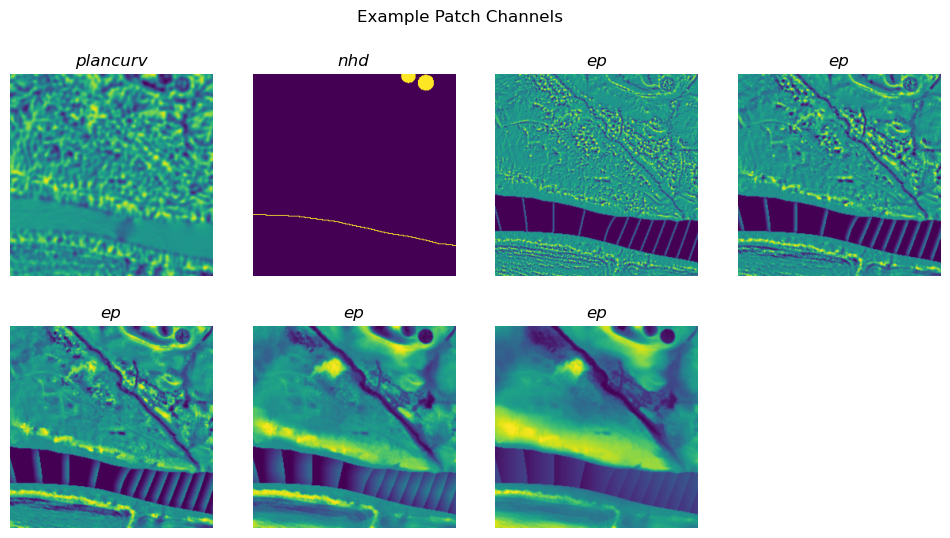

In [14]:

# extract total number of channels to plot...
num_channels = 0
for k,v in example.items():
    if not 'label' in k:
        num_channels += v.shape[1]

# define number of columns & rows...
ncols = min(4, num_channels)
nrows = (num_channels // ncols) + 1

# setup figure...
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 3*nrows))
ax = ax.ravel()

# plot channels separately...
idx = 0
for k,v in example.items():
    if 'label' in k:
        label = v.detach().numpy()[0]
        fig.suptitle(f"Example Patch Channels")
    else:
        v_sample = v.detach().numpy()[0]
        for c in range(v_sample.shape[0]):
            img = v_sample[c]
            min_val = img.min()
            max_val = img.max()
            img = (img - min_val) / (max_val - min_val + 1e-8)
            ax[idx].imshow(img)
            ax[idx].set_axis_off()
            ax[idx].set_title(k, style='italic')
            idx += 1

# remove any extra subplot axes...
for j in range(idx, len(ax)):
    fig.delaxes(ax[j])

plt.show()


# **Training**

In [ ]:
def training_log():
    
    ##### collect setup info
    metadata = {}
    metadata['NAME'] = model_name
    metadata['DIRECTORY'] = model_dir


    ##### collect patches info
    patches_meta = {}
    patches_meta['train patches'] = train_patch_path
    patches_meta['train patches directory'] = patch_dir
    patches_meta['validation patches'] = val_patch_path
    patches_meta['validation patches directory'] = patch_dir
    patches_meta['in-domain test patches'] = test_patch_path
    patches_meta['in-domain test patches directory'] = patch_dir
    patches_meta['cross-domain test patches'] = hardin_test_patch_path if not hardin_test_patch_path is None else None
    patches_meta['cross-domain test patches directory'] = hardin_patch_dir if not hardin_patch_dir is None else None
    metadata['PATCHES'] = patches_meta


    ##### collect modalitiy info
    modalities_meta = {}
    modalities_meta['modalities'] = modalities
    modalities_meta['normalization values'] = norm_params
    metadata['MODALITIES'] = modalities_meta


    ##### collect hyperparameters info
    hyper_meta = {}
    hyper_meta['batch size'] = batch_size
    hyper_meta['epochs'] = num_epochs
    hyper_meta['optimizer'] = type(optimizer).__name__
    hyper_meta['learning rate'] = optimizer.param_groups[0]['lr']
    hyper_meta['weight decay'] = optimizer.param_groups[0].get('weight_decay', None)
    hyper_meta['momentum'] = optimizer.param_groups[0].get('momentum', None)
    hyper_meta['loss'] = type(criterion).__name__
    hyper_meta['alpha'] = criterion.alpha.cpu().numpy().tolist()
    hyper_meta['gamma'] = criterion.gamma
    metadata['HYPERPARAMETERS'] = hyper_meta


    ##### collect model info
    model_meta = {}
    model_meta['encoder'] = type(encoder).__name__
    model_meta['weights'] = weights_config
    model_meta['attention'] = attention_configs
    model_meta['model'] = type(model).__name__
    metadata['MODEL'] = model_meta


    ##### write log to json
    with open(f"{model_dir}/metadata.json", 'w') as f:
        json.dump(metadata, f, indent=4)


    pass